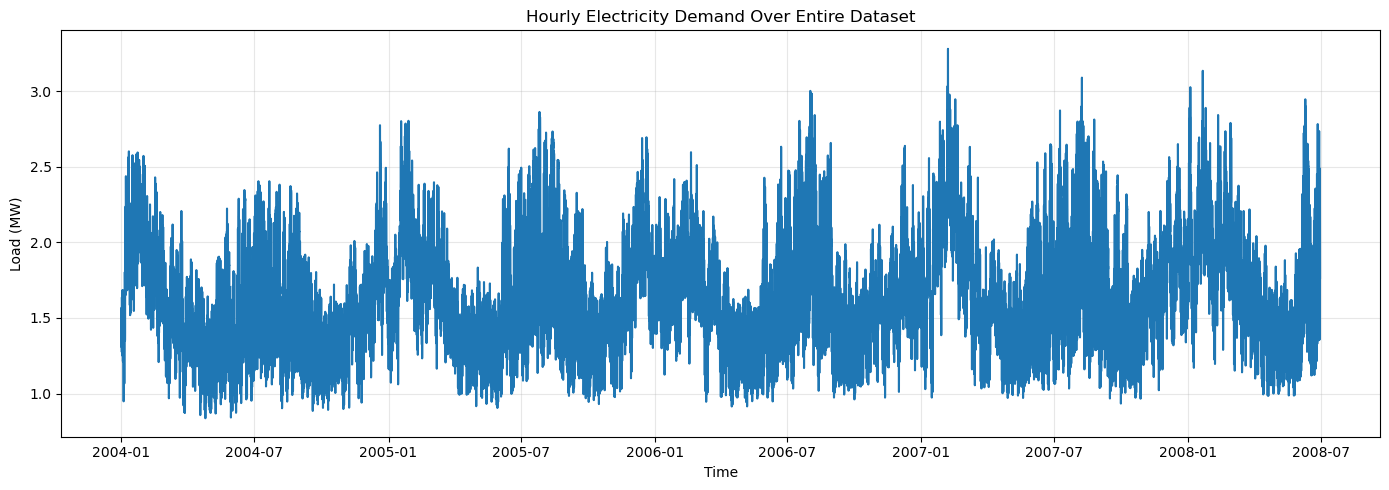

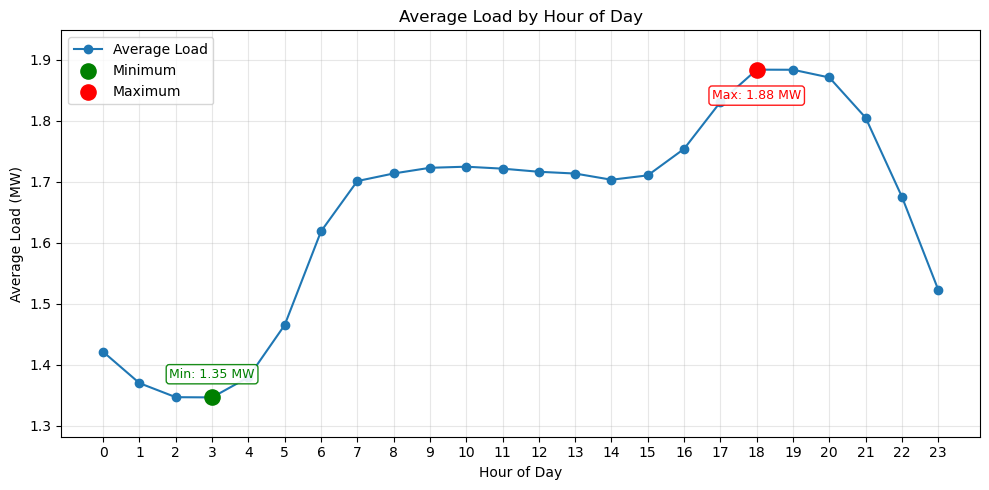

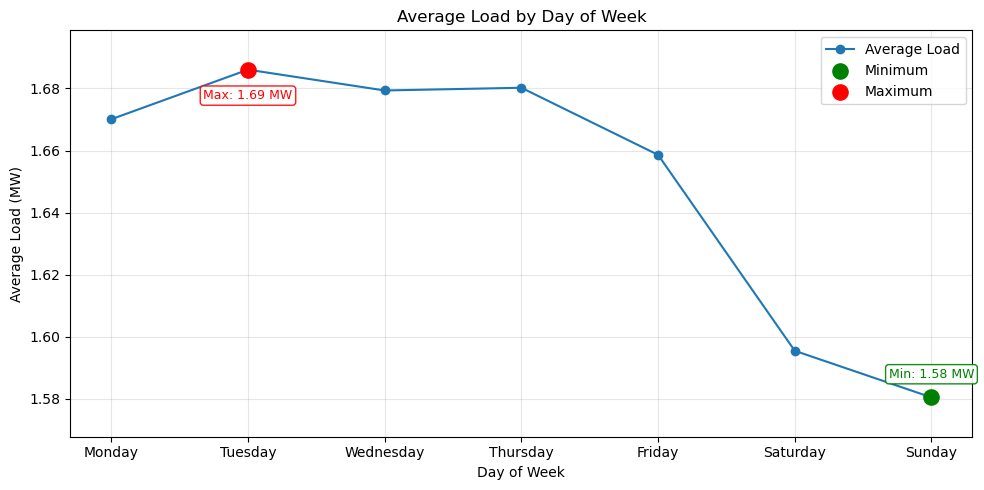

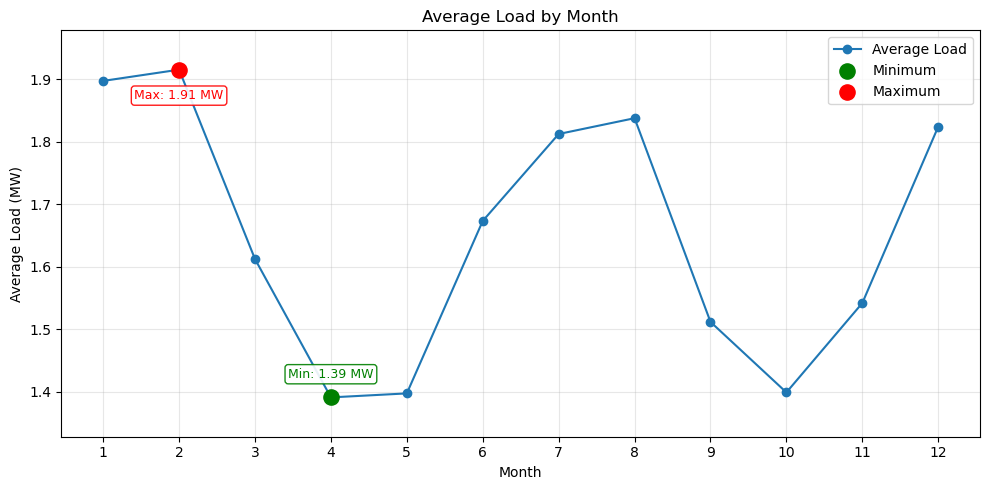

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import plotly.graph_objects as go

# -----------------------------
# Load data using a relative path
# -----------------------------
data_file = Path("load.csv")
df = pd.read_csv(data_file)

# -----------------------------
# Basic preprocessing
# -----------------------------
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

# Convert load from watts to megawatts
df["load_mw"] = df["load_sum"] / 1_000_000

# Create time-based features
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["day_name"] = df["timestamp"].dt.day_name()
df["month"] = df["timestamp"].dt.month
df["date"] = df["timestamp"].dt.date

# -----------------------------
# Aggregate data for plots
# -----------------------------
hourly_pattern = df.groupby("hour")["load_mw"].mean()

weekly_pattern = df.groupby("day_name")["load_mw"].mean().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)

monthly_pattern = df.groupby("month")["load_mw"].mean()
daily_series = df.groupby("date")["load_mw"].mean()

# -----------------------------
# Helper function to mark min/max
# -----------------------------
def annotate_min_max(ax, x, y):
    y_series = pd.Series(y)
    min_idx = y_series.idxmin()
    max_idx = y_series.idxmax()

    min_x = x[min_idx]
    max_x = x[max_idx]
    min_y = y_series[min_idx]
    max_y = y_series[max_idx]

    y_min = y_series.min()
    y_max = y_series.max()
    y_range = y_max - y_min

    if y_range == 0:
        y_range = abs(y_max) * 0.05 if y_max != 0 else 1

    pad = 0.12 * y_range
    ax.set_ylim(y_min - pad, y_max + pad)

    ax.scatter(min_x, min_y, s=120, color="green", zorder=5, label="Minimum")
    ax.scatter(max_x, max_y, s=120, color="red", zorder=5, label="Maximum")

    min_label = f"Min: {min_y:.2f} MW"
    max_label = f"Max: {max_y:.2f} MW"

    ax.annotate(
        min_label,
        xy=(min_x, min_y),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        color="green",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="green", alpha=0.9),
        clip_on=False
    )

    ax.annotate(
        max_label,
        xy=(max_x, max_y),
        xytext=(0, -14),
        textcoords="offset points",
        ha="center",
        va="top",
        fontsize=9,
        color="red",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="red", alpha=0.9),
        clip_on=False
    )

# -----------------------------
# Plot 1: Full hourly time series
# -----------------------------
plt.figure(figsize=(14, 5))
plt.plot(df["timestamp"], df["load_mw"])
plt.title("Hourly Electricity Demand Over Entire Dataset")
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 2: Average daily profile by hour of day
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hourly_pattern.index, hourly_pattern.values, marker="o", label="Average Load")
annotate_min_max(ax, list(hourly_pattern.index), hourly_pattern.values)
ax.set_title("Average Load by Hour of Day")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Load (MW)")
ax.set_xticks(range(0, 24))
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 3: Average weekly pattern
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(weekly_pattern.index, weekly_pattern.values, marker="o", label="Average Load")
annotate_min_max(ax, list(weekly_pattern.index), weekly_pattern.values)
ax.set_title("Average Load by Day of Week")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Load (MW)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 4: Average seasonal/monthly pattern
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_pattern.index, monthly_pattern.values, marker="o", label="Average Load")
annotate_min_max(ax, list(monthly_pattern.index), monthly_pattern.values)
ax.set_title("Average Load by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Average Load (MW)")
ax.set_xticks(range(1, 13))
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 5: Interactive daily average load trend
# -----------------------------
interactive_fig = go.Figure()

interactive_fig.add_trace(
    go.Scatter(
        x=list(daily_series.index),
        y=list(daily_series.values),
        mode="lines",
        name="Average Daily Load"
    )
)

interactive_fig.update_layout(
    title="Daily Average Load Trend (Interactive)",
    xaxis_title="Date",
    yaxis_title="Average Daily Load (MW)",
    template="plotly_white"
)

interactive_fig.show()